# Project Crashing Experiments
This notebook allows you to easily configure parameters and run the different project crashing scenarios.
The scenarios evaluate linear crashing (Base CP-SAT), non-linear crashing using Cobb-Douglas production functions (GA Metaheuristic & MILP), and a Hybrid approach.

In [1]:
import os
import sys
import pandas as pd
from IPython.display import Image, display

base_dir = os.path.abspath("")
sys.path.append(os.path.join(base_dir, "implementasi-base"))
sys.path.append(os.path.join(base_dir, "implementasi-cobb"))
sys.path.append(os.path.join(base_dir, "implementasi-hybrid"))

from solver_base import (
    read_json, build_predecessors, infer_activity_states_without_state_file,
    SolveConfig, build_model_and_solve, write_json, write_schedule_csv, 
    generate_gantt_comparison_plot, build_reference_no_crash_schedule
)

## Skenario 1: Base Model (CP-SAT Linear Crashing)
This model uses linear crashing costs per task and solves to exact optimality using Google OR-Tools CP-SAT.

Status: OPTIMAL
Makespan: 243 days
Total Crash Cost: $180.0


,activity,status,start,end,duration,normal_duration,min_duration,crash_days,crash_cost_per_day,crash_cost
0,Bids & Contracts,not_started,0,10,10,10,7,0,60.0,0.0
1,Interior Trim,not_started,0,20,20,20,15,0,50.0,0.0
2,Grading & Building Permits,not_started,10,20,10,10,7,0,70.0,0.0
3,Site Work,not_started,20,25,5,7,5,2,30.0,60.0
4,Floor Finishes,not_started,20,50,30,30,25,0,130.0,0.0
5,Foundation,not_started,25,47,22,22,18,0,80.0,0.0
6,Rough Carpentry,not_started,47,77,30,30,25,0,90.0,0.0
7,Electric Rough-in,not_started,77,96,19,19,14,0,55.0,0.0
8,Exterior Finishes,not_started,77,107,30,30,20,0,180.0,0.0
9,Roofing,not_started,107,137,30,30,25,0,200.0,0.0


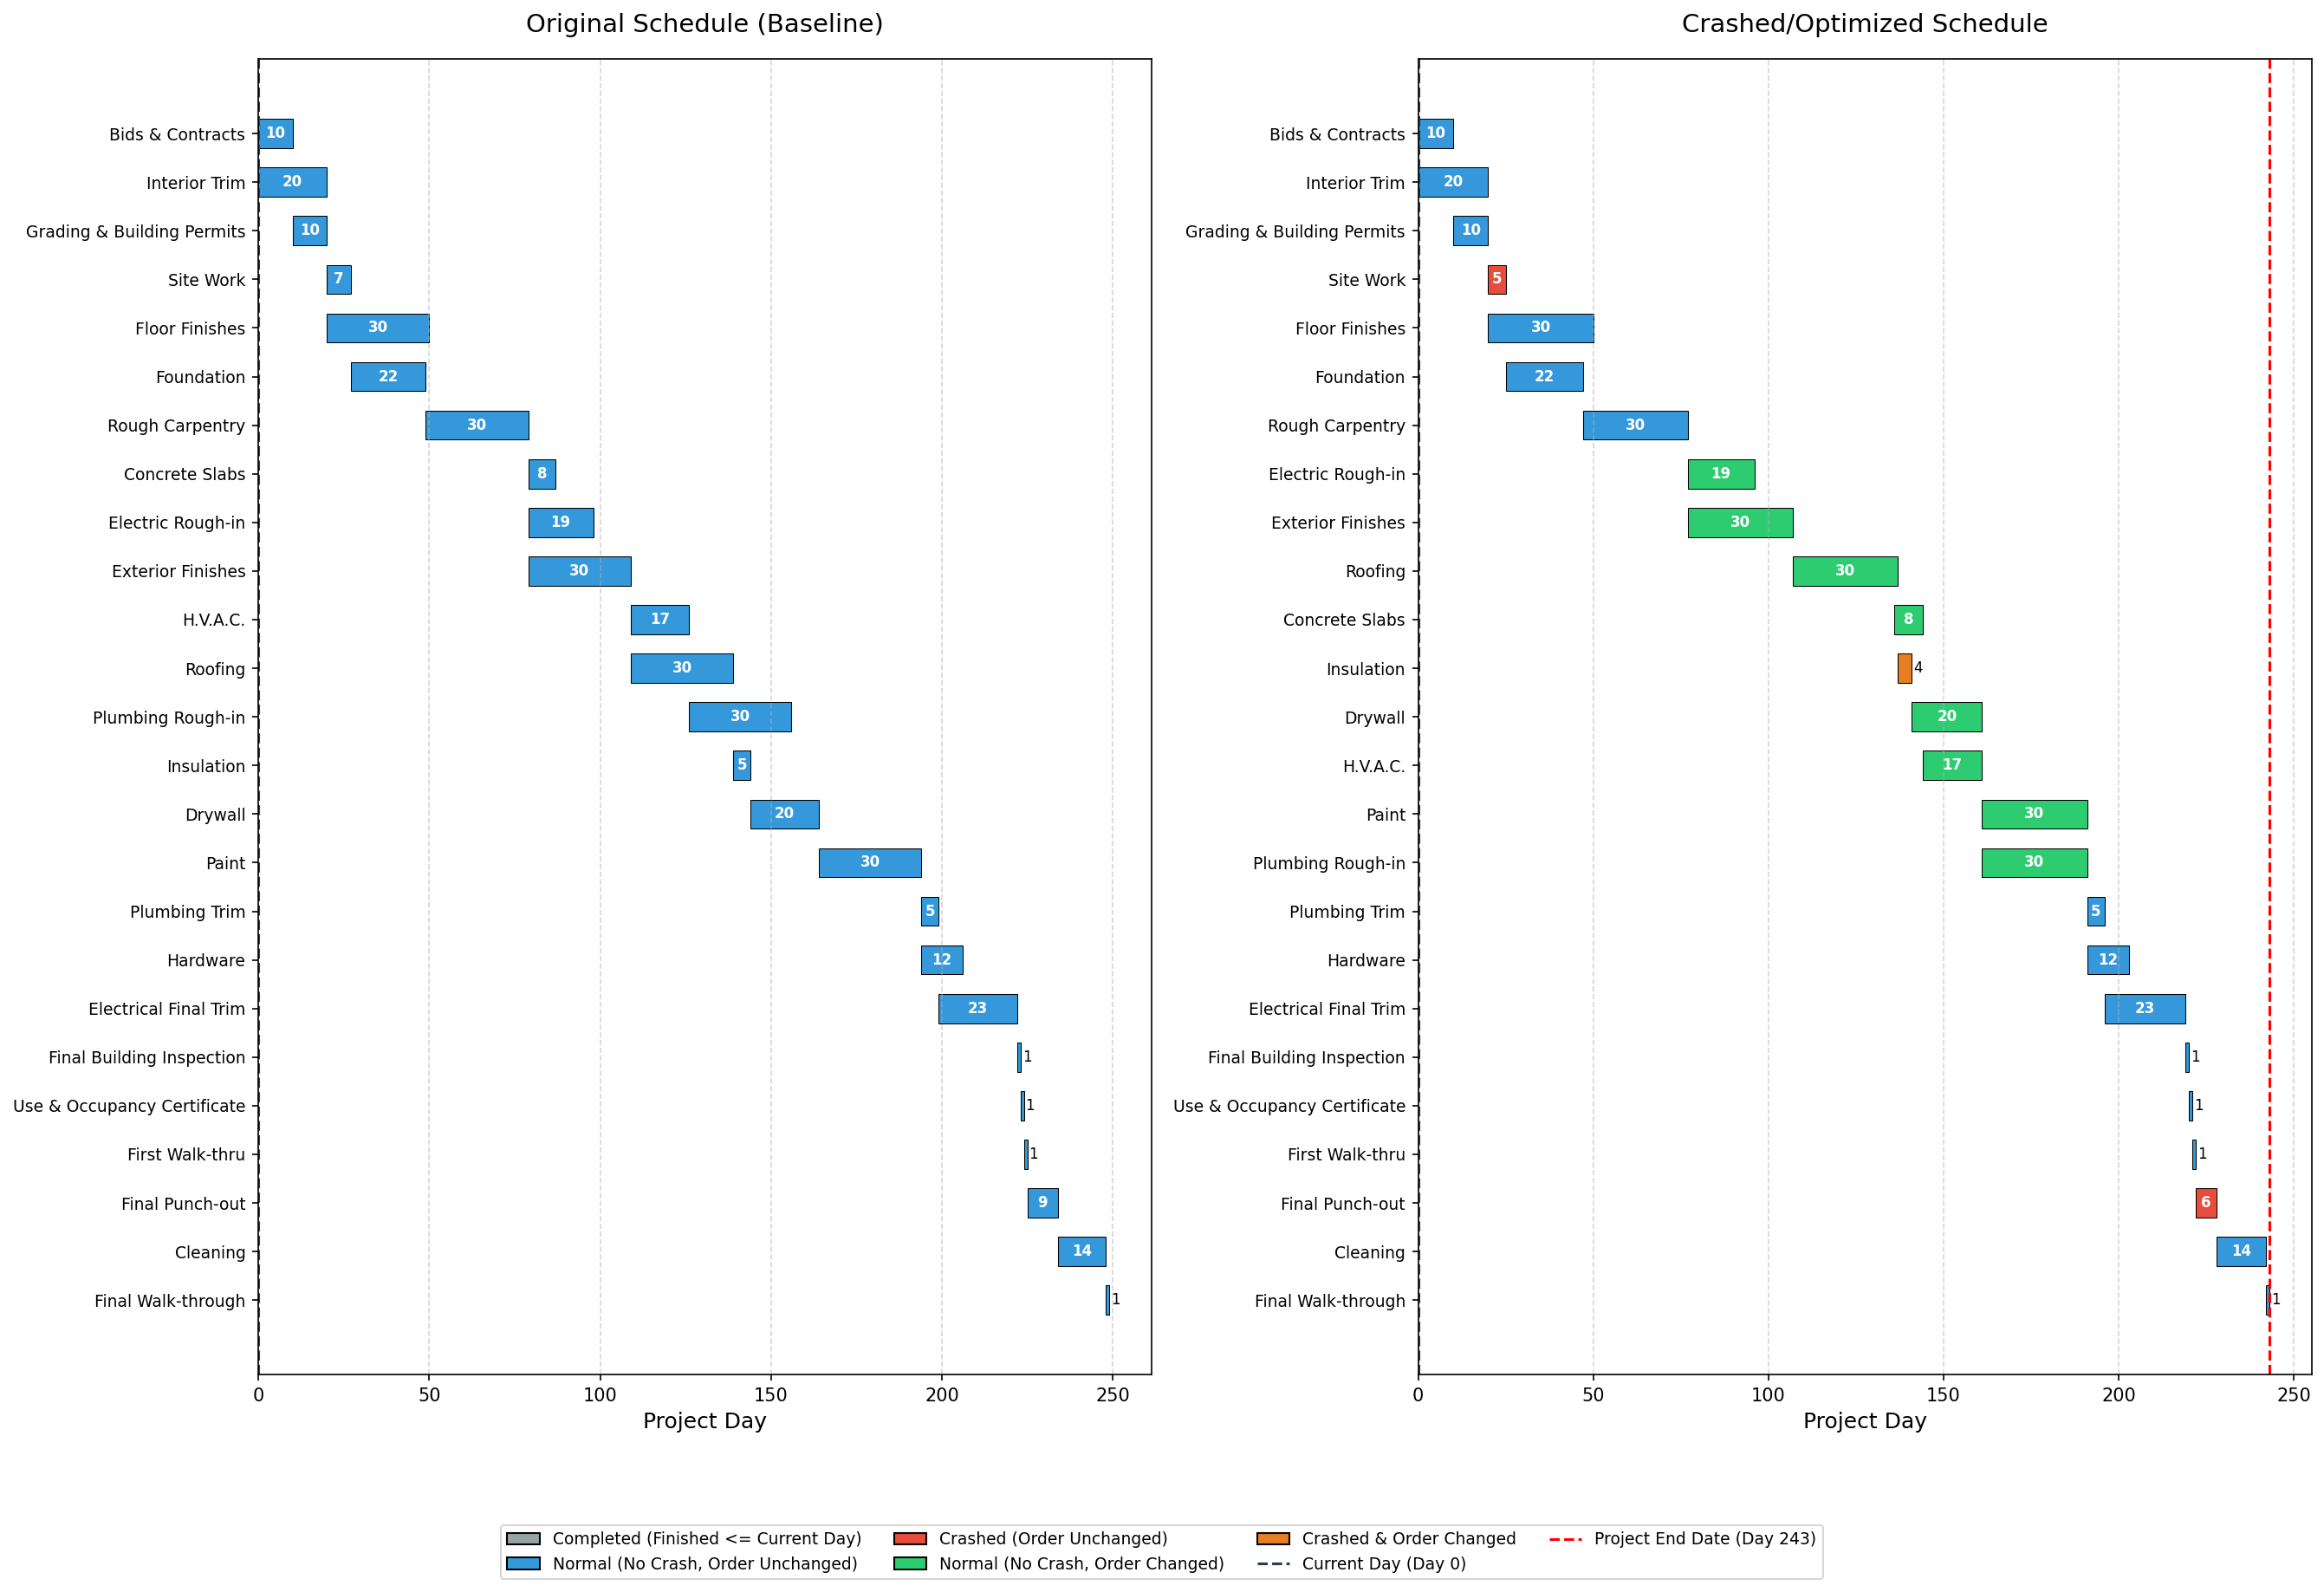

In [2]:
# Configure Parameters for Skenario 1
mode_1 = "cost_with_deadline" # Options: cost_with_deadline, time_with_budget, bonus_penalty
target_end_date_1 = 243
budget_limit_1 = 5000.0
c_late_1 = 1000.0
c_early_1 = 500.0
current_day_1 = 0

# Load Base Data
activity_data = read_json(os.path.join(base_dir, "data/activity_data_v3.json"))
resource_capacity = read_json(os.path.join(base_dir, "data/resource_capacity_v3.json"))
resource_req = read_json(os.path.join(base_dir, "data/resource_requirements_v3.json"))

predecessors, _ = build_predecessors(activity_data, [], True)
states, _ = infer_activity_states_without_state_file(
    activity_data, resource_req, resource_capacity, predecessors, current_day_1, 60.0, 1
)

cfg_1 = SolveConfig(
    target_end_date=target_end_date_1,
    budget_limit=budget_limit_1,
    c_late=c_late_1,
    c_early=c_early_1,
    current_day=current_day_1,
    time_limit=60.0,
    num_workers=1,
    auto_fix_paint_trim_cycle=True,
    remove_edges=[]
)

res_1 = build_model_and_solve(
    activity_data, resource_req, resource_capacity, predecessors, states, cfg_1, mode=mode_1
)

print(f"Status: {res_1['status']}")
if "makespan" in res_1:
    print(f"Makespan: {res_1['makespan']} days")
if "total_crash_cost" in res_1:
    print(f"Total Crash Cost: ${res_1['total_crash_cost']}")

# Display Schedule & Gantt Chart
if "schedule" in res_1:
    df_1 = pd.DataFrame(res_1['schedule'])
    display(df_1.head(10))
    
    baseline_1 = build_reference_no_crash_schedule(
        activity_data, resource_req, resource_capacity, predecessors, current_day_1, 60.0, 1
    )
    out_png_1 = os.path.join(base_dir, "outputs/base_gantt.png")
    os.makedirs(os.path.dirname(out_png_1), exist_ok=True)
    generate_gantt_comparison_plot(baseline_1, res_1["schedule"], current_day_1, out_png_1)
    display(Image(filename=out_png_1))

## Skenario 2: Cobb-Douglas Production Function (Genetic Algorithm)
This model uses a non-linear continuous production function for crashing. We solve it using the NSGA-II/GA metaheuristic algorithm.

*Note: For testing purposes in this notebook, `pop_size` and `n_gen` are set small. Increase them for a full run.*

Running Genetic Algorithm...
Makespan: 247.70 days


,Resource,x (Crowding),tau (Overtime),Original Duration,Crashed Duration
0,G.C. General Management,1.912277,0.762706,3.0,2.072868
1,G.C. Project Management,1.264045,0.236700,2.0,1.753142
2,G.C. General Management,1.012229,2.065691,2.0,1.772205
3,G.C. Project Management,1.178113,0.641508,2.0,1.772910
4,G.C. Scheduler,1.816086,0.064429,2.0,1.478155
5,G.C. General Management,1.078483,0.280597,2.0,1.892943
6,G.C. Project Management,1.533047,1.619859,2.0,1.473034
7,G.C. Project Management,1.982861,3.726326,4.0,2.346269
8,G.C. Procurement,1.375020,3.412685,4.0,2.855989
9,G.C. Project Management,1.739277,3.778414,10.0,6.249097


Saved Gantt chart comparison plot to: /Users/macintoshhd/Documents/Adiel/pemod/Pemod-3.0/project-crashing/outputs/cobb_ga_gantt.png


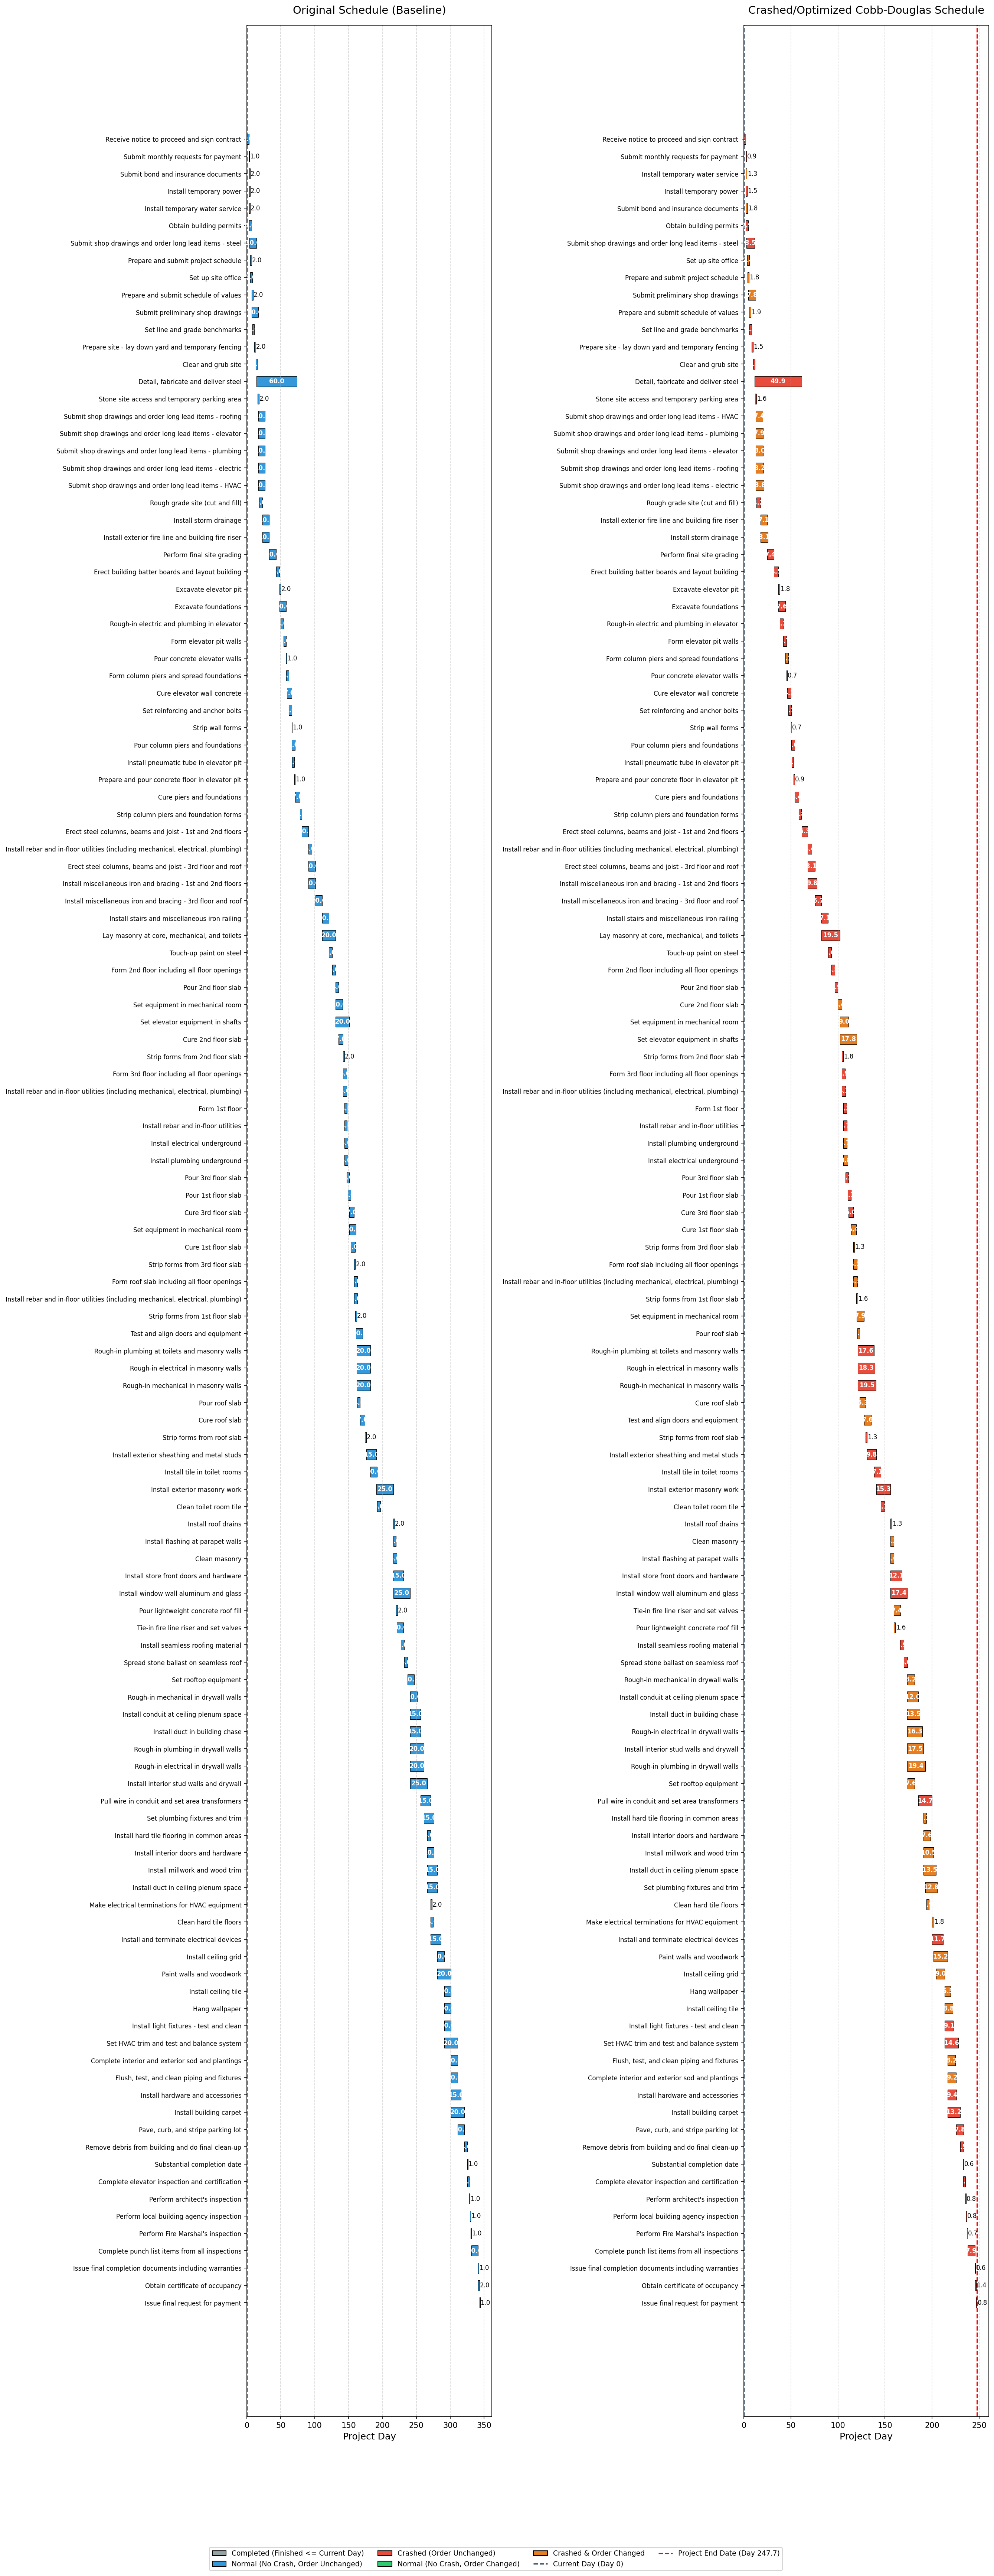

In [3]:
import numpy as np
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.termination import get_termination
from pymoo.optimize import minimize
from cobb_model import load_data, data_path, ResourceBasedScheduling, save_solution_json, generate_gantt_comparison_plot as cobb_gantt

# Configure Parameters for Skenario 2 (GA)
mode_2 = "bonus_penalty" # Options: cost_with_deadline, time_with_budget, bonus_penalty
T_MAX_2 = 310
BUDGET_LIMIT_2 = 500000.0
c_late_2 = 5000.0
c_early_2 = 2000.0

pop_size = 20  # INCREASE THIS FOR FULL RUN (e.g. 200)
n_gen = 20     # INCREASE THIS FOR FULL RUN (e.g. 100)

tasks, prec_2, res_2, N_2, K_i_2 = load_data(
    path_tasks=os.path.join(base_dir, "implementasi-cobb/data_tasks.csv"),
    path_precedence=os.path.join(base_dir, "implementasi-cobb/data_precedence.csv"),
    path_assignments=os.path.join(base_dir, "implementasi-cobb/data_assignments.csv"),
)

prob_2 = ResourceBasedScheduling(
    tasks=tasks, precedence=prec_2, resources=res_2, N=N_2, K_i=K_i_2,
    T_max=T_MAX_2, mode=mode_2, budget_limit=BUDGET_LIMIT_2, c_late=c_late_2, c_early=c_early_2
)

algorithm_2 = GA(pop_size=pop_size, crossover=SBX(prob=0.9, eta=15), mutation=PM(eta=20))
termination_2 = get_termination("n_gen", n_gen)

print("Running Genetic Algorithm...")
res_ga = minimize(prob_2, algorithm_2, termination_2, seed=42, verbose=False)

if res_ga.X is not None:
    P = prob_2.P
    x_opt = res_ga.X
    x_ik_opt = x_opt[0:P]
    tau_ik_opt = x_opt[P:2*P]
    D_ik_opt, D_i_opt = prob_2.compute_durations(x_opt)
    s_opt, f_opt = prob_2.forward_pass(D_i_opt)
    
    print(f"Makespan: {np.max(f_opt):.2f} days")
    
    df_var = pd.DataFrame({
        "Resource": res_2["resource_name"],
        "x (Crowding)": x_ik_opt,
        "tau (Overtime)": tau_ik_opt,
        "Original Duration": res_2["D_base_ik"],
        "Crashed Duration": D_ik_opt
    })
    display(df_var.head(10))
    
    out_png_2 = os.path.join(base_dir, "outputs/cobb_ga_gantt.png")
    os.makedirs(os.path.dirname(out_png_2), exist_ok=True)
    cobb_gantt(tasks, prob_2.s_baseline, prob_2.f_baseline, s_opt, f_opt, current_day_1, out_png_2)
    display(Image(filename=out_png_2))
else:
    print("No feasible solution found.")

Running Genetic Algorithm...
n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      200 |      9 |  0.000000E+00 |  0.000000E+00 |             - |             -
     2 |      400 |     15 |  0.000000E+00 |  0.000000E+00 |  0.1431469340 |         ideal
     3 |      600 |     17 |  0.000000E+00 |  0.000000E+00 |  0.0867958502 |         ideal
     4 |      800 |     11 |  0.000000E+00 |  0.000000E+00 |  0.1402437887 |         ideal
     5 |     1000 |     24 |  0.000000E+00 |  0.000000E+00 |  0.1913582725 |         ideal
     6 |     1200 |     19 |  0.000000E+00 |  0.000000E+00 |  0.0435898846 |             f
     7 |     1400 |     19 |  0.000000E+00 |  0.000000E+00 |  0.0713834447 |         ideal
     8 |     1600 |     27 |  0.000000E+00 |  0.000000E+00 |  0.0530487982 |         ideal
     9 |     1800 |     15 |  0.000000E+00 |  0.000000E+00 |  0.0155259156 |         ideal
    10 |     2000 |     15 |  0.000000E+00 |  0.000000E+00 | 

,Resource,x (Crowding),tau (Overtime),Original Duration,Crashed Duration
0,G.C. General Management,1.919412,0.049517,3.0,2.158724
1,G.C. Project Management,1.321061,0.423436,2.0,1.695777
2,G.C. General Management,1.214087,0.249935,2.0,1.787413
3,G.C. Project Management,1.019183,2.685986,2.0,1.714122
4,G.C. Scheduler,1.371635,1.453042,2.0,1.570978
5,G.C. General Management,1.385855,1.661346,2.0,1.545957
6,G.C. Project Management,1.072259,0.148772,2.0,1.913723
7,G.C. Project Management,1.401299,0.018508,4.0,3.375148
8,G.C. Procurement,1.039443,0.360712,4.0,3.837806
9,G.C. Project Management,1.017264,1.231383,10.0,9.229851


Saved Gantt chart comparison plot to: /Users/macintoshhd/Documents/Adiel/pemod/Pemod-3.0/project-crashing/outputs/cobb_ga_gantt.png


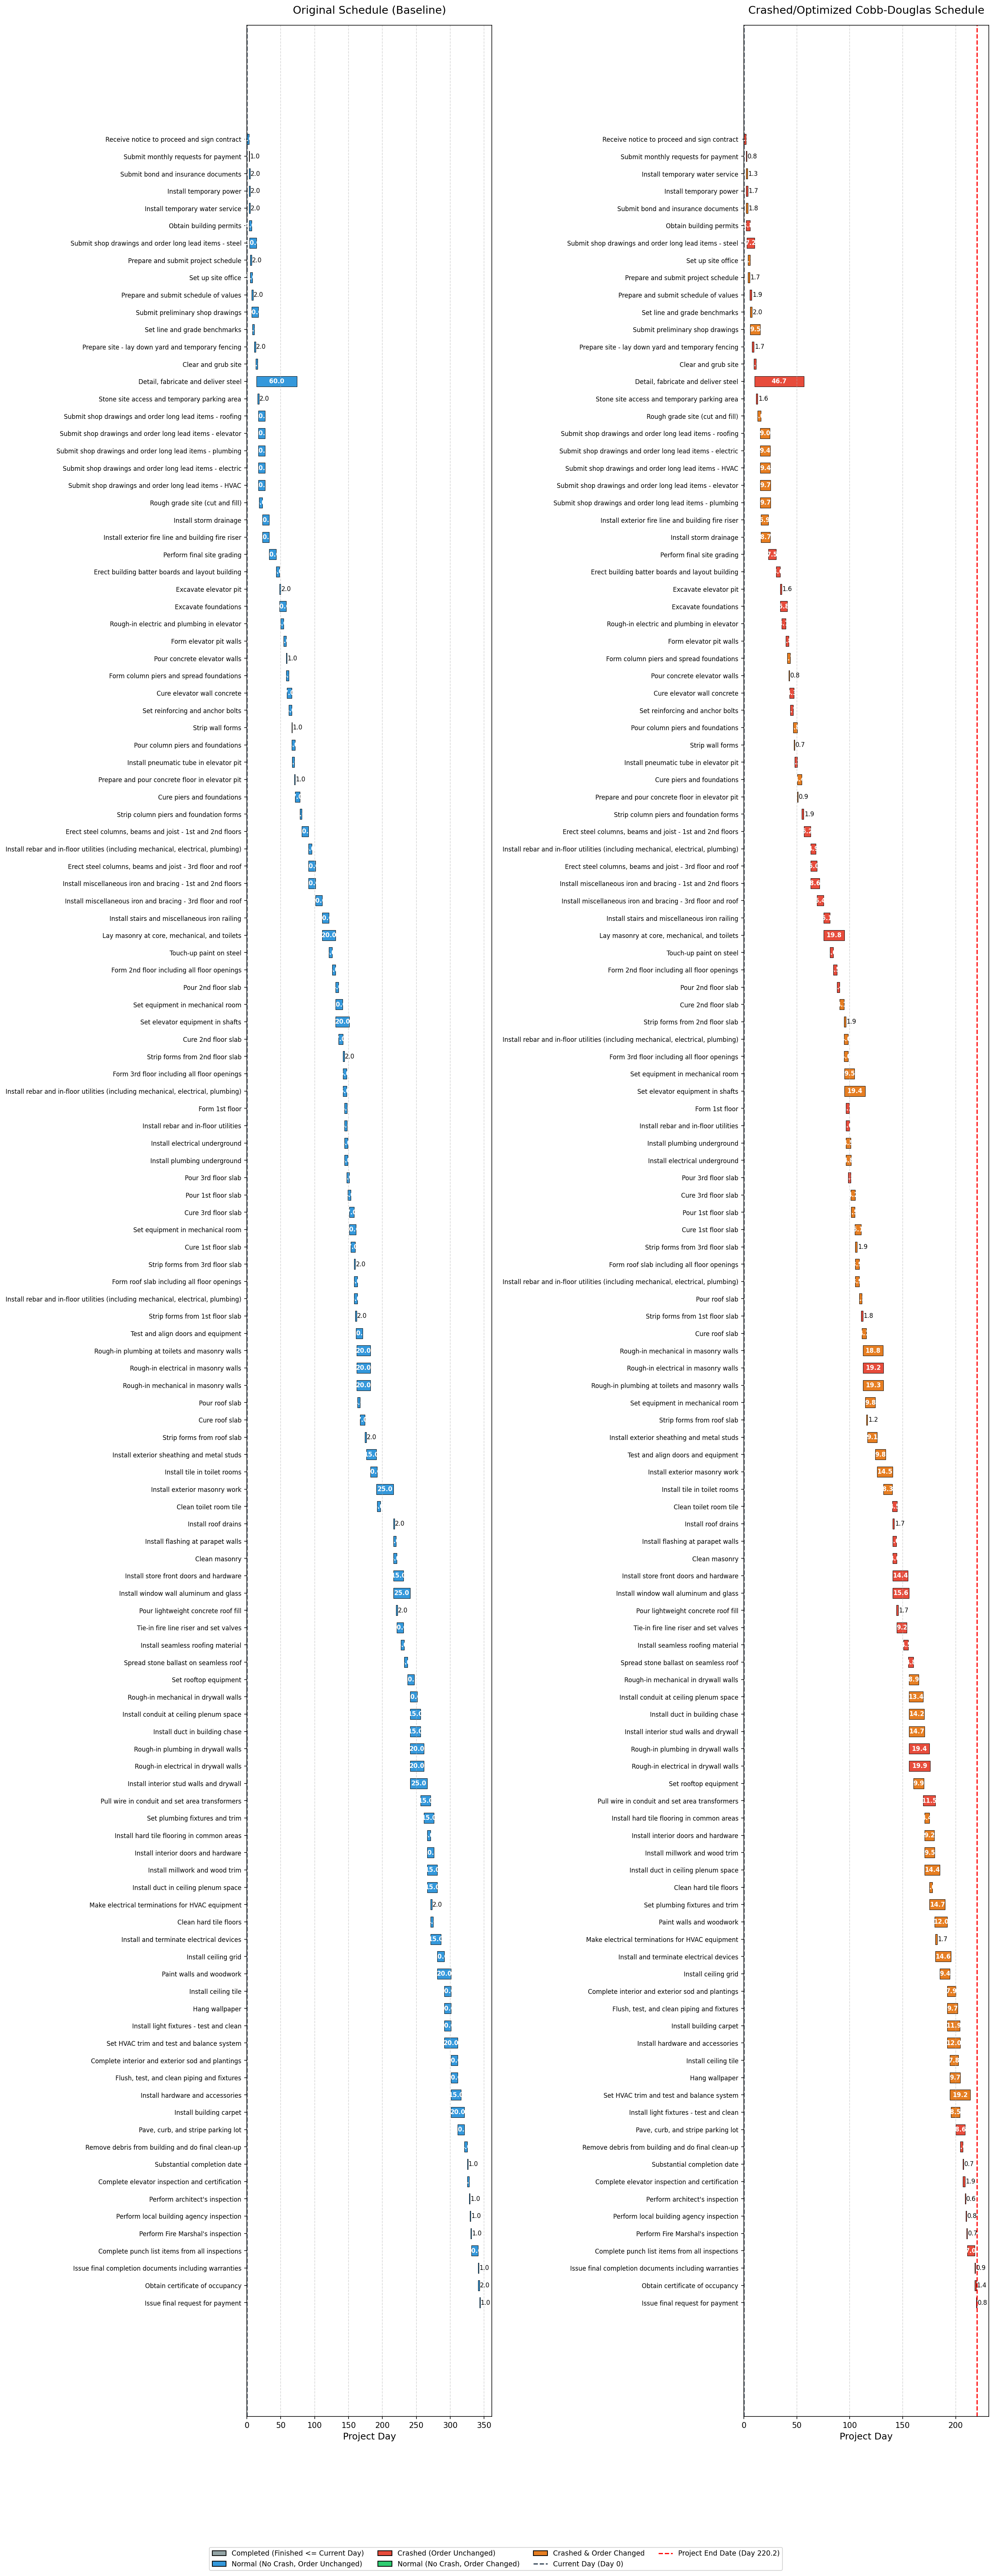

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt                          # + add this import
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.algorithms.moo.nsga2 import NSGA2            # + add
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.core.termination import Termination           # + add
from pymoo.termination.ftol import MultiObjectiveSpaceTermination  # + add
from pymoo.termination.robust import RobustTermination   # + add
from pymoo.termination import get_termination
from pymoo.optimize import minimize
from cobb_model import load_data, data_path, ResourceBasedScheduling, save_solution_json, generate_gantt_comparison_plot as cobb_gantt

# Configure Parameters for Skenario 2 (GA)
mode_2 = "multiobjective"  # ← change this to switch mode
                            # Options: cost_with_deadline, time_with_budget, bonus_penalty, multiobjective
T_MAX_2 = 310
BUDGET_LIMIT_2 = 500000.0
c_late_2 = 5000.0
c_early_2 = 2000.0
current_day_1 = 0

pop_size = 200   # INCREASE THIS FOR FULL RUN (e.g. 200)
n_gen = 100      # INCREASE THIS FOR FULL RUN (e.g. 100)

tasks, prec_2, res_2, N_2, K_i_2 = load_data(
    path_tasks=data_path("data_tasks.csv"),
    path_precedence=data_path("data_precedence.csv"),
    path_assignments=data_path("data_assignments.csv"),
)

prob_2 = ResourceBasedScheduling(
    tasks=tasks, precedence=prec_2, resources=res_2, N=N_2, K_i=K_i_2,
    T_max=T_MAX_2, mode=mode_2, budget_limit=BUDGET_LIMIT_2, c_late=c_late_2, c_early=c_early_2
)

# + algorithm and termination now branch on mode
if mode_2 == "multiobjective":
    algorithm_2 = NSGA2(
        pop_size=200, crossover=SBX(prob=0.9, eta=15), mutation=PM(eta=20),
        eliminate_duplicates=True,
    )
    t_robust = RobustTermination(MultiObjectiveSpaceTermination(tol=0.002, n_skip=5), period=30)
    t_max_gen = get_termination("n_gen", 300)

    class CombinedTermination(Termination):
        def __init__(self, t1, t2):
            super().__init__()
            self.t1 = t1
            self.t2 = t2
        def _update(self, algorithm):
            return max(self.t1.update(algorithm), self.t2.update(algorithm))

    termination_2 = CombinedTermination(t_robust, t_max_gen)
else:
    algorithm_2 = GA(pop_size=pop_size, crossover=SBX(prob=0.9, eta=15), mutation=PM(eta=20))
    termination_2 = get_termination("n_gen", n_gen)

print("Running Genetic Algorithm...")
res_ga = minimize(prob_2, algorithm_2, termination_2, seed=42, verbose=True)

if mode_2 == "multiobjective":
    if res_ga.F is not None and res_ga.X is not None:
        # Pick the solution with minimum makespan from the Pareto front
        best_idx = np.argmin(res_ga.F[:, 0])
        x_opt = res_ga.X[best_idx]

        P = prob_2.P
        x_ik_opt  = x_opt[0:P]
        tau_ik_opt = x_opt[P:2*P]
        D_ik_opt, D_i_opt = prob_2.compute_durations(x_opt)
        s_opt, f_opt = prob_2.forward_pass(D_i_opt)

        print(f"Makespan: {np.max(f_opt):.2f} days")

        df_var = pd.DataFrame({
            "Resource": res_2["resource_name"],
            "x (Crowding)": x_ik_opt,
            "tau (Overtime)": tau_ik_opt,
            "Original Duration": res_2["D_base_ik"],
            "Crashed Duration": D_ik_opt
        })
        display(df_var.head(10))

        out_png_2 = os.path.join(base_dir, "outputs/cobb_ga_gantt.png")
        os.makedirs(os.path.dirname(out_png_2), exist_ok=True)
        cobb_gantt(tasks, prob_2.s_baseline, prob_2.f_baseline, s_opt, f_opt, current_day_1, out_png_2)
        display(Image(filename=out_png_2))
    else:
        print("Multi-objective: No feasible solutions found.")

else:
    # original single-objective block — unchanged
    if res_ga.X is not None:
        P = prob_2.P
        x_opt = res_ga.X
        x_ik_opt = x_opt[0:P]
        tau_ik_opt = x_opt[P:2*P]
        D_ik_opt, D_i_opt = prob_2.compute_durations(x_opt)
        s_opt, f_opt = prob_2.forward_pass(D_i_opt)

        print(f"Makespan: {np.max(f_opt):.2f} days")

        df_var = pd.DataFrame({
            "Resource": res_2["resource_name"],
            "x (Crowding)": x_ik_opt,
            "tau (Overtime)": tau_ik_opt,
            "Original Duration": res_2["D_base_ik"],
            "Crashed Duration": D_ik_opt
        })
        display(df_var.head(10))

        out_png_2 = os.path.join(base_dir, "outputs/cobb_ga_gantt.png")
        os.makedirs(os.path.dirname(out_png_2), exist_ok=True)
        cobb_gantt(tasks, prob_2.s_baseline, prob_2.f_baseline, s_opt, f_opt, current_day_1, out_png_2)
        display(Image(filename=out_png_2))
    else:
        print("No feasible solution found.")

## Skenario 2: Cobb-Douglas (Multi-Objective Optimization via NSGA-II)
We can also perform multi-objective optimization using the NSGA-II algorithm to minimize both Makespan and Labor Cost simultaneously, finding the Pareto Front of optimal trade-offs.

Running NSGA-II Multi-Objective Optimization...
n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      200 |      1 |  0.000000E+00 |  0.5437685920 |             - |             -
     2 |      400 |      2 |  0.000000E+00 |  0.1891081254 |  1.0000000000 |         ideal
     3 |      600 |      5 |  0.000000E+00 |  0.0905389432 |  0.2253145353 |         ideal
     4 |      800 |      6 |  0.000000E+00 |  0.0423270541 |  0.2644266712 |         ideal
     5 |     1000 |      7 |  0.000000E+00 |  0.0193387985 |  0.0641743467 |         ideal
     6 |     1200 |      8 |  0.000000E+00 |  0.0086241878 |  0.0671097855 |             f
     7 |     1400 |      6 |  0.000000E+00 |  0.0034826335 |  0.0781308862 |             f
     8 |     1600 |      8 |  0.000000E+00 |  0.0004074545 |  0.1117123101 |         ideal
     9 |     1800 |      9 |  0.000000E+00 |  0.000000E+00 |  0.2508443917 |         ideal
    10 |     2000 |     12 |  0.000000E+00

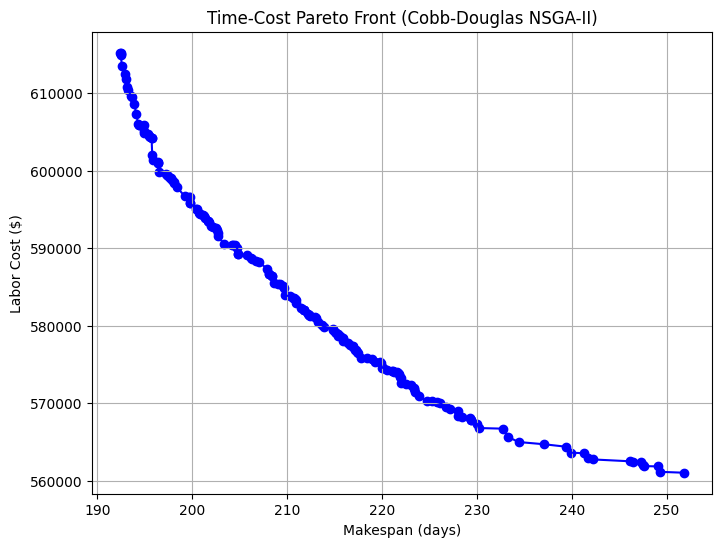

Saved Pareto front plot to: /Users/macintoshhd/Documents/Adiel/pemod/Pemod-3.0/project-crashing/outputs/cobb_pareto_front.png


In [5]:
import matplotlib.pyplot as plt
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.termination import Termination
from pymoo.termination.ftol import MultiObjectiveSpaceTermination
from pymoo.termination.robust import RobustTermination

problem_moo = ResourceBasedScheduling(
    tasks=tasks, precedence=prec_2, resources=res_2, N=N_2, K_i=K_i_2,
    alpha=0.7, beta=0.7, x_min=1.0, tau_min=0.0, tau_max=4.0, D_min_ratio=0.5,
    T_max=344, current_day=current_day_1, overtime_mult=1.5, hours_per_day=8,
    mode="multiobjective"
)

algorithm_moo = NSGA2(
    pop_size=200, crossover=SBX(prob=0.9, eta=15), mutation=PM(eta=20),
    eliminate_duplicates=True,
)

t_robust = RobustTermination(MultiObjectiveSpaceTermination(tol=0.002, n_skip=5), period=30)
t_max_gen = get_termination("n_gen", 300)

class CombinedTermination(Termination):
    def __init__(self, t1, t2):
        super().__init__()
        self.t1 = t1
        self.t2 = t2
    def _update(self, algorithm):
        return max(self.t1.update(algorithm), self.t2.update(algorithm))
        
termination_moo = CombinedTermination(t_robust, t_max_gen)

print("Running NSGA-II Multi-Objective Optimization...")
res_moo = minimize(problem_moo, algorithm_moo, termination_moo, seed=42, verbose=True)

if res_moo.F is not None:
    F = res_moo.F
    # Sort by makespan for plotting
    sorted_indices = np.argsort(F[:, 0])
    F_sorted = F[sorted_indices]
    
    plt.figure(figsize=(8, 6))
    plt.scatter(F_sorted[:, 0], F_sorted[:, 1], color='b', marker='o')
    plt.plot(F_sorted[:, 0], F_sorted[:, 1], color='b', linestyle='-')
    plt.xlabel('Makespan (days)')
    plt.ylabel('Labor Cost ($)')
    plt.title('Time-Cost Pareto Front (Cobb-Douglas NSGA-II)')
    plt.grid(True)
    
    out_pareto = os.path.join(base_dir, "outputs/cobb_pareto_front.png")
    os.makedirs(os.path.dirname(out_pareto), exist_ok=True)
    plt.savefig(out_pareto, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved Pareto front plot to: {out_pareto}")
else:
    print("Multi-objective: No feasible solutions found.")

## Skenario 2: Cobb-Douglas (MILP Discretization via CP-SAT)
Alternatively, we can discretize the Cobb-Douglas variables ($x \in [1.0, 1.5, 2.0]$ and $\tau \in \{0, 1, 2, 3, 4\}$) and solve the problem exactly using CP-SAT.

In [6]:
from solver_milp import solve_milp_cobb_douglas

mode_milp = "cost_with_deadline"
T_MAX_MILP = 344

print("Running MILP Exact Solver...")
solve_milp_cobb_douglas(
    tasks, prec_2, res_2, N_2, K_i_2,
    mode=mode_milp, T_max=T_MAX_MILP, time_limit=30.0
)

Running MILP Exact Solver...
MILP Solver: Status=OPTIMAL, Makespan=344, Labor Cost=506209.991
Wrote solution JSON to: /Users/macintoshhd/Documents/Adiel/pemod/Pemod-3.0/project-crashing/implementasi-cobb/../outputs/milp_cobb_cost_with_deadline.json


## Skenario 3: Hybrid Model (Preprocessing + CP-SAT)
In this scenario, we estimate the cost of crashing linearly from the non-linear Cobb-Douglas function, then feed the estimated bounds into the standard CP-SAT model.

Preprocessing Hybrid Data...
Preprocessing completed. Files saved to /Users/macintoshhd/Documents/Adiel/pemod/Pemod-3.0/project-crashing/implementasi-hybrid/data
Hybrid Model Status: OPTIMAL
Makespan: 286 days
Estimated Crash Cost: $19992.56


,activity,status,start,end,duration,normal_duration,min_duration,crash_days,crash_cost_per_day,crash_cost
0,2,not_started,0,3,3,3,2,0,1194.47,0.0
1,8,not_started,3,4,1,1,1,0,298.62,0.0
2,18,not_started,3,5,2,2,1,0,647.01,0.0
3,19,not_started,3,5,2,2,1,0,647.01,0.0
4,3,not_started,3,5,2,2,1,0,1244.24,0.0
5,6,not_started,3,7,4,4,2,0,846.08,0.0
6,10,not_started,4,14,10,10,5,0,846.08,0.0
7,20,not_started,5,8,3,3,2,0,875.95,0.0
8,21,not_started,8,11,3,3,2,0,647.01,0.0
9,22,not_started,11,13,2,2,1,0,726.64,0.0


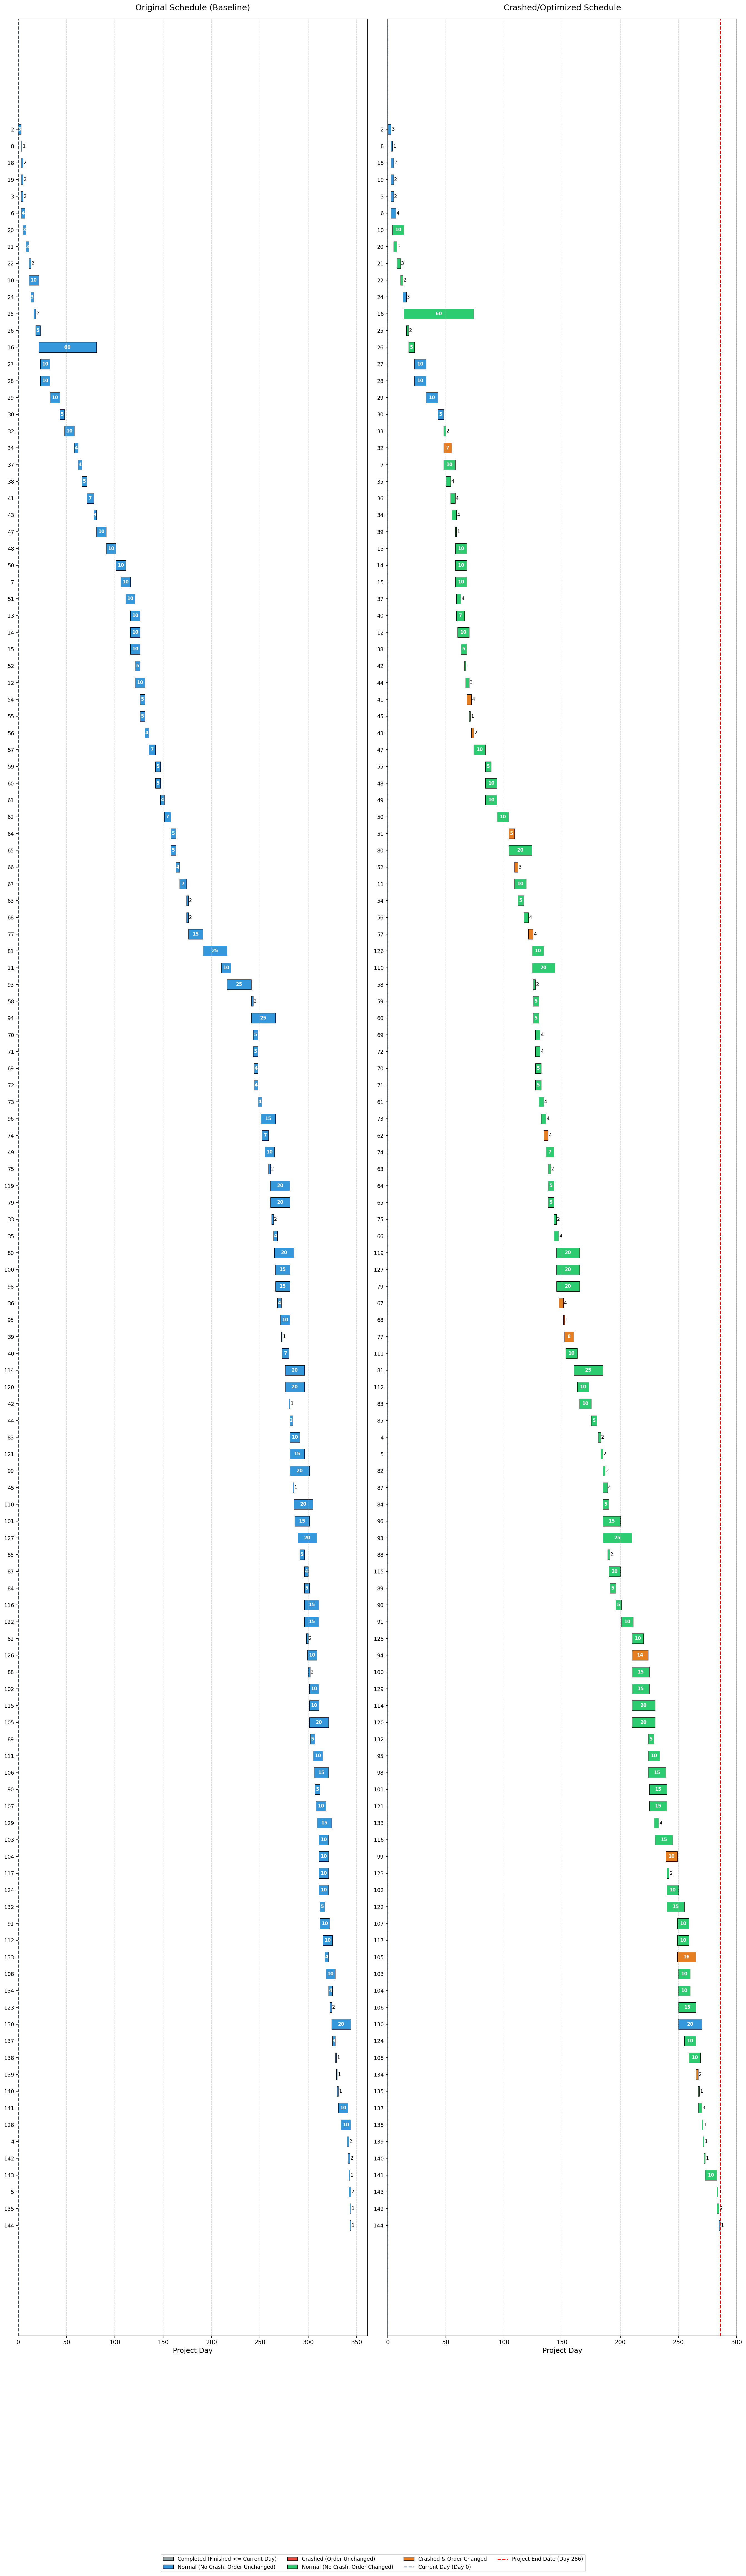

In [7]:
import preprocessing

print("Preprocessing Hybrid Data...")
# Ensure preprocessing writes to implementasi-hybrid/data correctly
preprocessing.preprocess()

act_hyb = read_json(os.path.join(base_dir, "implementasi-hybrid/data/activity_data.json"))
cap_hyb = read_json(os.path.join(base_dir, "implementasi-hybrid/data/resource_capacity.json"))
req_hyb = read_json(os.path.join(base_dir, "implementasi-hybrid/data/resource_requirements.json"))

mode_3 = "time_with_budget"
target_end_date_3 = 310
budget_limit_3 = 20000.0

pred_hyb, _ = build_predecessors(act_hyb, [], True)
states_hyb, _ = infer_activity_states_without_state_file(
    act_hyb, req_hyb, cap_hyb, pred_hyb, 0, 60.0, 1
)

cfg_3 = SolveConfig(
    target_end_date=target_end_date_3, budget_limit=budget_limit_3,
    time_limit=30.0, num_workers=1, auto_fix_paint_trim_cycle=True,
    remove_edges=[], current_day=0
)

res_3 = build_model_and_solve(
    act_hyb, req_hyb, cap_hyb, pred_hyb, states_hyb, cfg_3, mode=mode_3
)

print(f"Hybrid Model Status: {res_3['status']}")
if "makespan" in res_3:
    print(f"Makespan: {res_3['makespan']} days")
if "total_crash_cost" in res_3:
    print(f"Estimated Crash Cost: ${res_3['total_crash_cost']}")
    
if "schedule" in res_3:
    display(pd.DataFrame(res_3['schedule']).head(10))
    
    baseline_3 = build_reference_no_crash_schedule(
        act_hyb, req_hyb, cap_hyb, pred_hyb, 0, 60.0, 1
    )
    out_png_3 = os.path.join(base_dir, "outputs/hybrid_gantt.png")
    os.makedirs(os.path.dirname(out_png_3), exist_ok=True)
    generate_gantt_comparison_plot(baseline_3, res_3["schedule"], 0, out_png_3)
    display(Image(filename=out_png_3))